<a href="https://colab.research.google.com/github/Lekhana-Y/ML/blob/main/k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [9]:
df = pd.read_csv("store_customers.csv")

print(df.head())
print(df.columns)

   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0        1000      M  39.0                59.9                    58.0
1        1001      M  34.0                48.4                    37.0
2        1002      F  40.0                70.5                    26.0
3        1003      F  47.0                81.1                    30.0
4        1004      F  33.0                42.1                    58.0
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


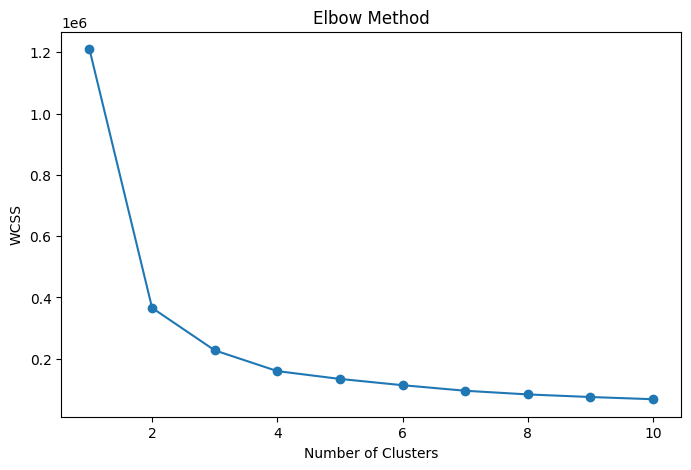

In [12]:
X=df[["Annual Income (k$)","Spending Score (1-100)"]]
X=X.dropna()

wcss=[]

for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=42,n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

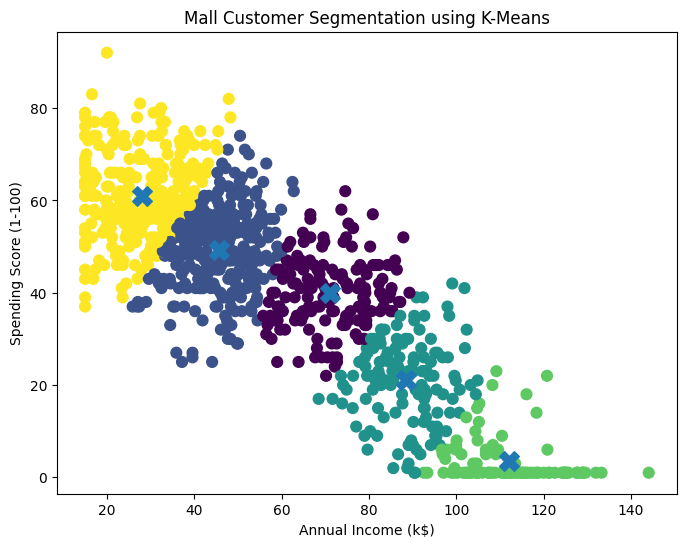

     Annual Income (k$)  Spending Score (1-100)  Cluster
0                  59.9                    58.0        1
1                  48.4                    37.0        1
2                  70.5                    26.0        0
3                  81.1                    30.0        2
4                  42.1                    58.0        1
..                  ...                     ...      ...
995               133.3                     1.0        3
996                82.6                    40.0        0
997                67.7                    26.0        0
998                45.7                    59.0        1
999               107.8                     1.0        3

[990 rows x 3 columns]


In [13]:
kmeans=KMeans(n_clusters=5,random_state=42,n_init=10)
clusters=kmeans.fit_predict(X)

plt.figure(figsize=(8,6))
plt.scatter(X["Annual Income (k$)"],X["Spending Score (1-100)"],c=clusters,s=60)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=200,marker="X")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Mall Customer Segmentation using K-Means")
plt.show()

X["Cluster"]=clusters
print(X)